In [1]:

import pandas as pd
import numpy as np
from scipy.io import arff
import io
import re
from collections import Counter

def load_arff_with_unique_attribute_names(path):
	with open(path, "r", encoding="utf-8", errors="replace") as f:
		lines = f.readlines()

	attr_counter = Counter()
	out_lines = []
	attr_pattern = re.compile(
		r"""^\s*@attribute\s+(?:'([^']*)'|"([^"]*)"|(\S+))""",
		re.IGNORECASE,
	)

	for line in lines:
		match = attr_pattern.match(line)
		if match:
			name = match.group(1) or match.group(2) or match.group(3)
			attr_counter[name] += 1
			if attr_counter[name] > 1:
				unique_name = f"{name}_{attr_counter[name] - 1}"
				line = attr_pattern.sub(f"@attribute '{unique_name}'", line, count=1)
		out_lines.append(line)

	return arff.loadarff(io.StringIO("".join(out_lines)))


data, meta = load_arff_with_unique_attribute_names(
	"../data/Amazon_initial_50_30_10000.arff"
)

df = pd.DataFrame(data)



In [2]:
df

,the,and,a,of,to,is,I,in,that,it,...,ra_,le_to,bra,uch_a,ave_a,n_in_,ied_,nd_b,rso,class_1
0,5.0,3.0,4.0,4.0,1.0,5.0,1.0,3.0,2.0,4.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,b'Agresti'
1,12.0,3.0,6.0,2.0,3.0,4.0,2.0,0.0,1.0,3.0,...,0.0,0.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,b'Agresti'
2,3.0,2.0,2.0,4.0,4.0,2.0,2.0,2.0,3.0,1.0,...,0.0,0.0,6.0,0.0,0.0,0.0,0.0,1.0,0.0,b'Agresti'
3,18.0,4.0,6.0,5.0,4.0,2.0,1.0,0.0,4.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'Agresti'
4,13.0,4.0,7.0,5.0,4.0,5.0,0.0,1.0,0.0,4.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,b'Agresti'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,15.0,11.0,5.0,9.0,10.0,0.0,5.0,6.0,1.0,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,b'Wilson'
1496,12.0,7.0,7.0,5.0,5.0,3.0,3.0,2.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'Wilson'
1497,8.0,10.0,2.0,4.0,2.0,0.0,2.0,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'Wilson'
1498,11.0,12.0,10.0,7.0,8.0,4.0,4.0,7.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,b'Wilson'


In [3]:
df['class_1'] = df['class_1'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))

df = df.drop(columns=['class'])

df = df.rename(columns={'class_1': 'class'})

print("Shape:", df.shape)
print("\nAutores únicos:", df['class'].nunique())
print("\nReseñas por autor:")
print(df['class'].value_counts())

Shape: (1500, 10000)

Autores únicos: 50

Reseñas por autor:
class
Agresti        30
Ashbacher      30
Auken          30
Blankenship    30
Brody          30
Brown          30
Bukowsky       30
Calvinnme      30
CFH            30
Chachra        30
Chandler       30
Chell          30
Cholette       30
Comdet         30
Corn           30
Cutey          30
Davisson       30
Dent           30
Engineer       30
Goonan         30
Grove          30
Harp           30
Hayes          30
Janson         30
Johnson        30
Koenig         30
Kolln          30
Lawyeraau      30
Lee            30
Lovitt         30
Mahlers2nd     30
Mark           30
McKee          30
Merritt        30
Messick        30
Mitchell       30
Morrison       30
Neal           30
Nigam          30
Peterson       30
Power          30
Riley          30
Robert         30
Shea           30
Sherwin        30
Taylor         30
Vernon         30
Vision         30
Walters        30
Wilson         30
Name: count, dtype: int64


## Limpieza de datos

In [4]:
# 1. Valores faltantes
missing = df.isnull().sum()
print(f"missing values: {missing[missing > 0].shape[0]}")

missing values: 0


In [5]:
# 2. Duplicados
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 20


In [6]:
# 3. Tipo de datos
print("\nTipos de datos")
print(df.dtypes.value_counts())


Tipos de datos
float64    9999
str           1
Name: count, dtype: int64


In [7]:
# 4. Verificar balance de clases
print(f"Reseñas por autor:\n{df['class'].value_counts().describe()}")

Reseñas por autor:
count    50.0
mean     30.0
std       0.0
min      30.0
25%      30.0
50%      30.0
75%      30.0
max      30.0
Name: count, dtype: float64


In [8]:
# Eliminar duplicados
df = df.drop_duplicates()
print(f"\nDuplicates: {df.duplicated().sum()}")


Duplicates: 0


## Análisis descriptivo

In [9]:
# Separar features y target
X = df.drop(columns=['class'])
y = df['class']

# Estadísticas descriptivas generales
print("=== Estadísticas Descriptivas ===")
stats = X.describe().T
print(stats[['mean', 'std', 'min', '50%', 'max']])

=== Estadísticas Descriptivas ===
            mean       std  min   50%   max
the    11.741216  5.634572  0.0  11.0  32.0
and     7.471622  3.569915  0.0   7.0  21.0
a       6.709459  3.369620  0.0   6.0  20.0
of      6.530405  3.842103  0.0   6.0  25.0
to      6.187838  3.374303  0.0   6.0  24.0
...          ...       ...  ...   ...   ...
ave_a   0.203378  0.477898  0.0   0.0   4.0
n_in_   0.204054  0.479728  0.0   0.0   4.0
ied_    0.206757  0.497956  0.0   0.0   5.0
nd_b    0.203378  0.463534  0.0   0.0   3.0
rso     0.203378  0.536550  0.0   0.0   4.0

[9999 rows x 5 columns]


In [10]:
# Top 10 features con mayor media (palabras más usadas)
print("Top 10 features con mayor media")
print(X.mean().sort_values(ascending=False).head(10))

# Top 10 features con mayor varianza (más discriminativas)
print("\nTop 10 features con mayor varianza")
print(X.var().sort_values(ascending=False).head(10))

# Distribución general de valores
print("\nDistribución general")
print(f"Features con media = 0: {(X.mean() == 0).sum()}")
print(f"Features con media < 1: {(X.mean() < 1).sum()}")
print(f"Features con media >= 1: {(X.mean() >= 1).sum()}")

Top 10 features con mayor media
_     249.631081
o      86.252703
n      73.025676
r      66.692568
h      56.417568
l      48.577703
e_     41.200676
_t     33.115541
c      31.608784
u      31.525000
dtype: float64

Top 10 features con mayor varianza
_     4382.606200
o      665.428999
n      521.624763
r      429.789803
h      307.929644
l      243.931754
e_     181.085463
c      136.534473
_t     130.685086
u      122.204919
dtype: float64

Distribución general
Features con media = 0: 0
Features con media < 1: 9351
Features con media >= 1: 648


In [11]:
# Estadisticas por autor
print("\nEstadísticas por Autor")
top_features = X.mean().sort_values(ascending=False).head(5).index.tolist()
print(df.groupby('class')[top_features].mean().round(2))


Estadísticas por Autor
                  _       o      n      r      h
class                                           
Agresti      215.67   70.17  55.33  55.20  49.00
Ashbacher    218.24   74.07  64.69  59.14  53.83
Auken        225.41   76.10  71.59  70.10  44.93
Blankenship  300.63  102.87  84.00  73.93  71.33
Brody        192.83   63.70  56.17  50.47  44.57
Brown        185.17   64.67  48.13  46.20  46.07
Bukowsky     287.20  104.97  97.53  87.10  69.43
CFH          259.74   90.33  70.04  68.70  50.52
Calvinnme    254.59   87.90  75.72  66.97  55.03
Chachra      154.73   47.43  39.17  35.90  32.43
Chandler     324.23  112.53  84.03  75.77  66.93
Chell        239.03   86.93  74.17  65.53  53.13
Cholette     270.13   91.80  79.83  74.53  63.83
Comdet       277.77   91.77  69.17  64.47  59.53
Corn         224.77   81.07  65.17  53.57  51.20
Cutey        196.43   64.07  52.67  40.97  40.30
Davisson     282.90   91.69  78.38  70.00  60.76
Dent         249.85   81.15  64.89  59.48  48

Chandler y Sherwin escriben reseñas más largas (media _ > 300)

Chachra y McKee escriben reseñas más cortas (media _ < 180)

## Visualizaciones Gráficas


Se muestran distribuciones generales, diferencias entre autores y relaciones entre variables numericas con mayor presencia o variabilidad en el dataset.

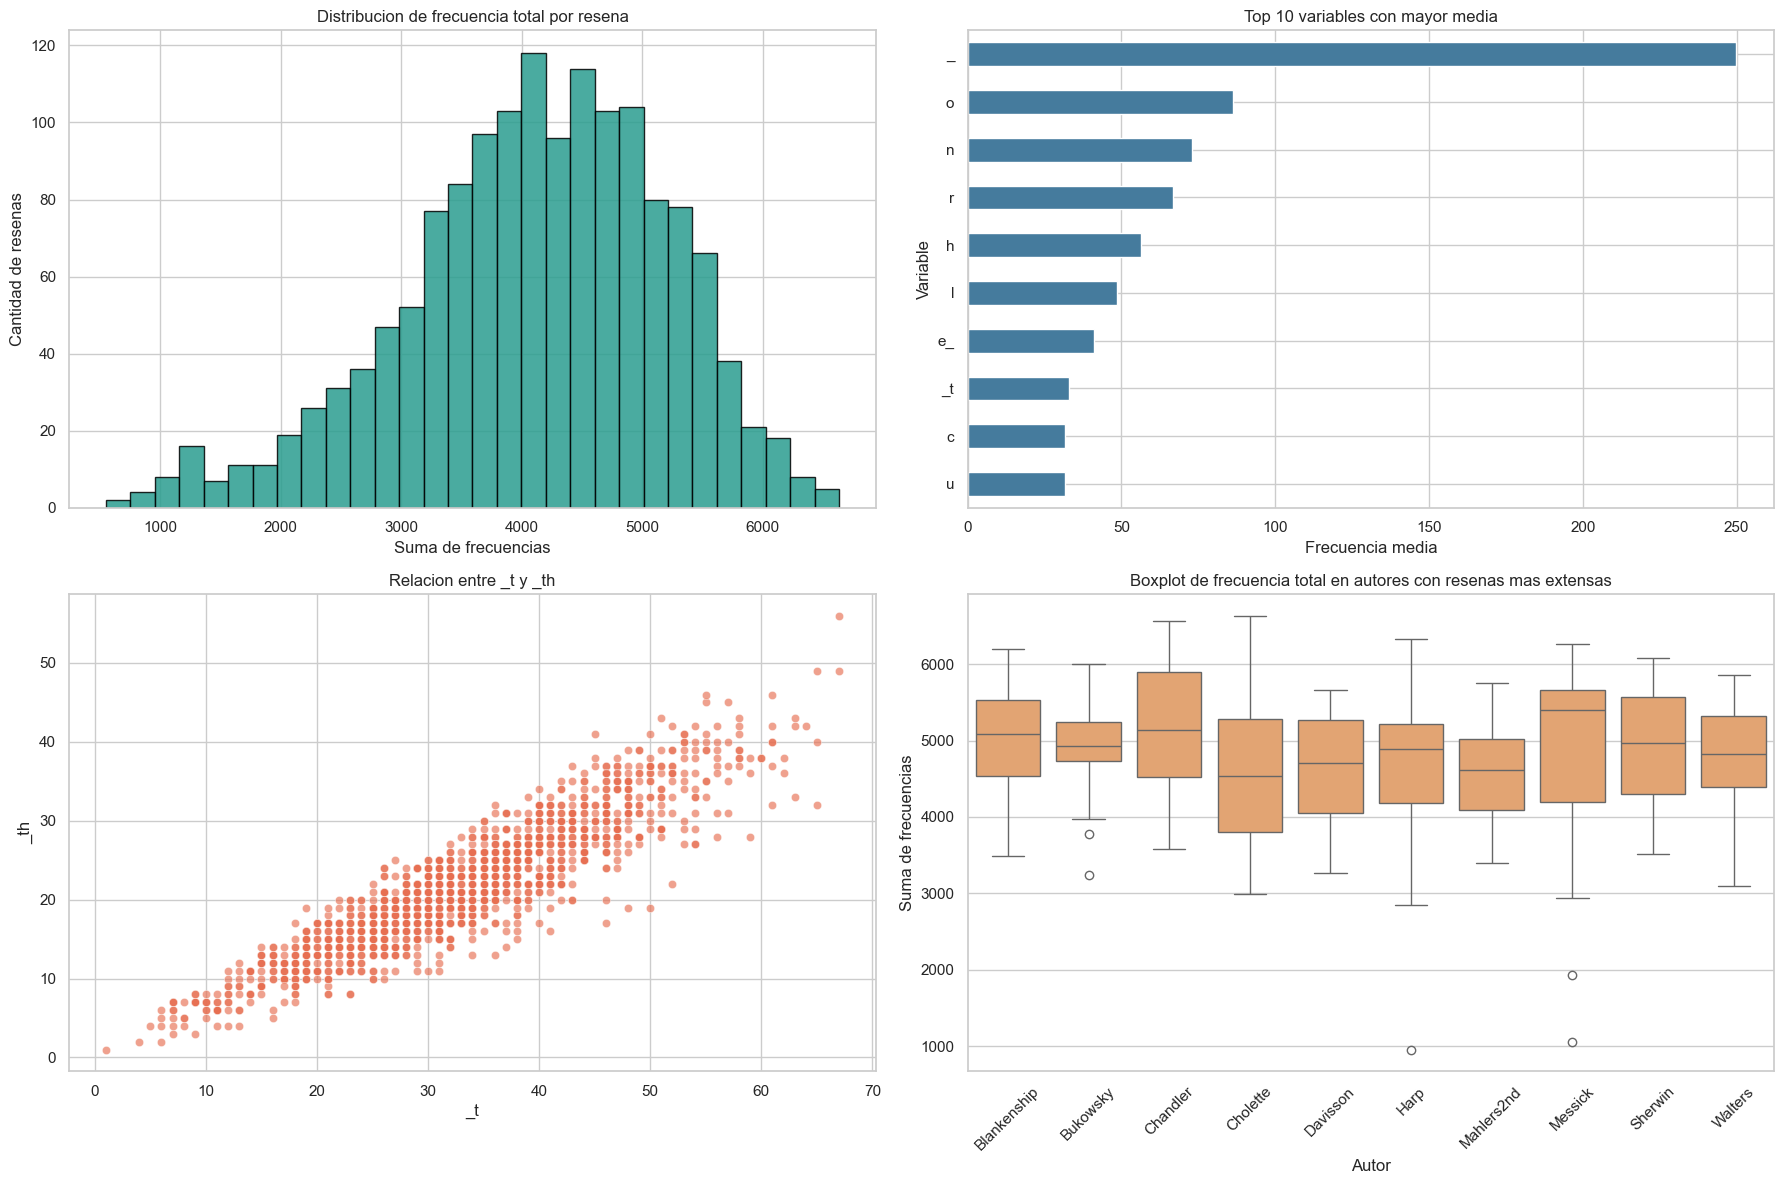

Variables usadas en el scatterplot: _t y _th
Variables con mayor media:
_     249.631081
o      86.252703
n      73.025676
r      66.692568
h      56.417568
l      48.577703
e_     41.200676
_t     33.115541
c      31.608784
u      31.525000
dtype: float64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

total_frecuencia = X.sum(axis=1)
top_mean_features = X.mean().sort_values(ascending=False).head(10)

autores_mas_extensos = (
    df.assign(total_frecuencia=total_frecuencia)
    .groupby("class")["total_frecuencia"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

df_boxplot = df[df["class"].isin(autores_mas_extensos.index)].copy()
df_boxplot["total_frecuencia"] = total_frecuencia[df_boxplot.index]

corr_candidates = X[X.var().sort_values(ascending=False).head(20).index]
corr_candidates_matrix = corr_candidates.corr()
upper = corr_candidates_matrix.where(
    np.triu(np.ones(corr_candidates_matrix.shape), k=1).astype(bool)
)
feature_x, feature_y = upper.stack().sort_values(
    key=lambda s: s.abs(), ascending=False
).index[0]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].hist(
    total_frecuencia,
    bins=30,
    color="#2a9d8f",
    edgecolor="black",
    alpha=0.85
)
axes[0, 0].set_title("Distribucion de frecuencia total por resena")
axes[0, 0].set_xlabel("Suma de frecuencias")
axes[0, 0].set_ylabel("Cantidad de resenas")

top_mean_features.sort_values().plot(
    kind="barh",
    ax=axes[0, 1],
    color="#457b9d"
)
axes[0, 1].set_title("Top 10 variables con mayor media")
axes[0, 1].set_xlabel("Frecuencia media")
axes[0, 1].set_ylabel("Variable")

sns.scatterplot(
    data=df.assign(total_frecuencia=total_frecuencia),
    x=feature_x,
    y=feature_y,
    alpha=0.65,
    ax=axes[1, 0],
    color="#e76f51"
)
axes[1, 0].set_title(f"Relacion entre {feature_x} y {feature_y}")
axes[1, 0].set_xlabel(feature_x)
axes[1, 0].set_ylabel(feature_y)

sns.boxplot(
    data=df_boxplot,
    x="class",
    y="total_frecuencia",
    ax=axes[1, 1],
    color="#f4a261"
)
axes[1, 1].set_title("Boxplot de frecuencia total en autores con resenas mas extensas")
axes[1, 1].set_xlabel("Autor")
axes[1, 1].set_ylabel("Suma de frecuencias")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Variables usadas en el scatterplot:", feature_x, "y", feature_y)
print("Variables con mayor media:")
print(top_mean_features)


### Visualizaciones por autor

Se incluyen visualizaciones orientadas a comparar estilos de escritura entre autores. En particular, se analiza la frecuencia total promedio por reseña y la distribucion de una de las variables mas frecuentes del conjunto.


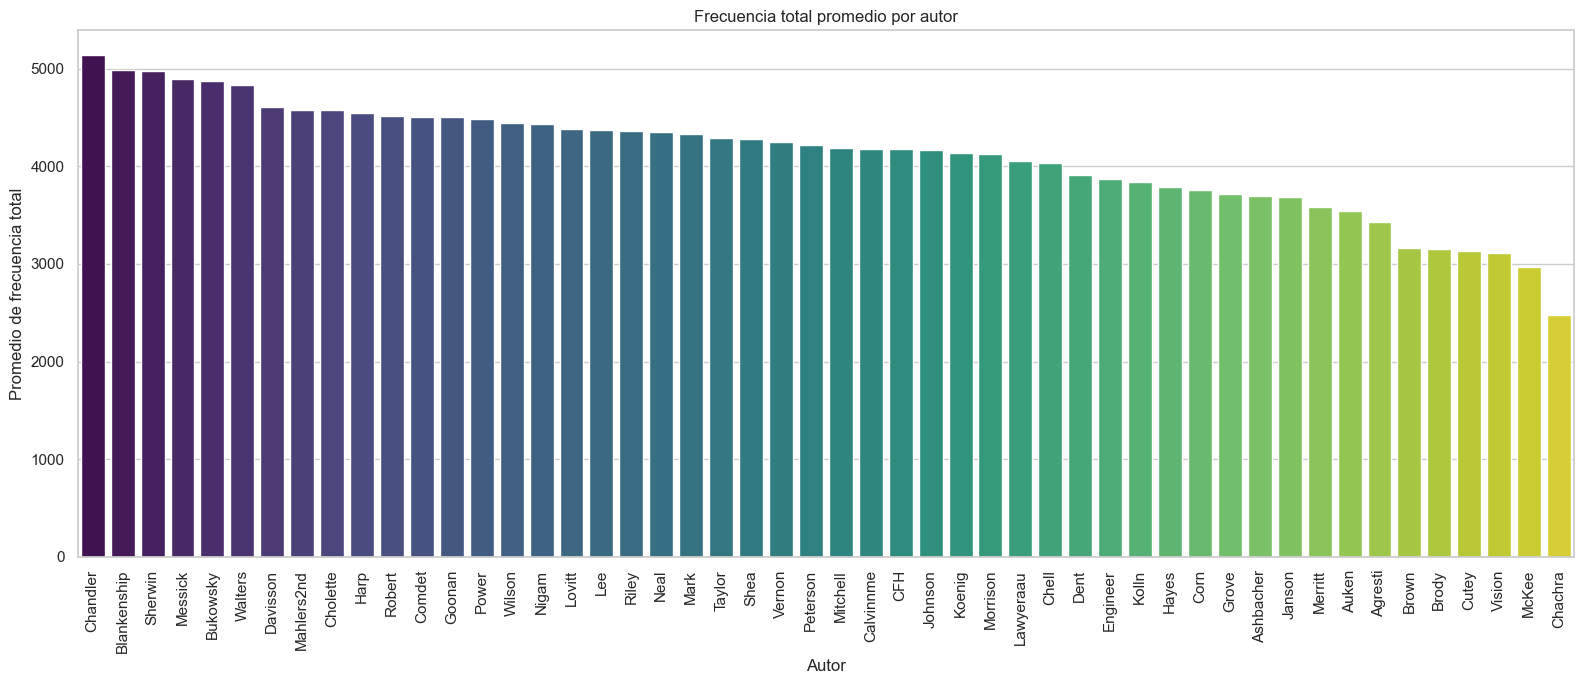

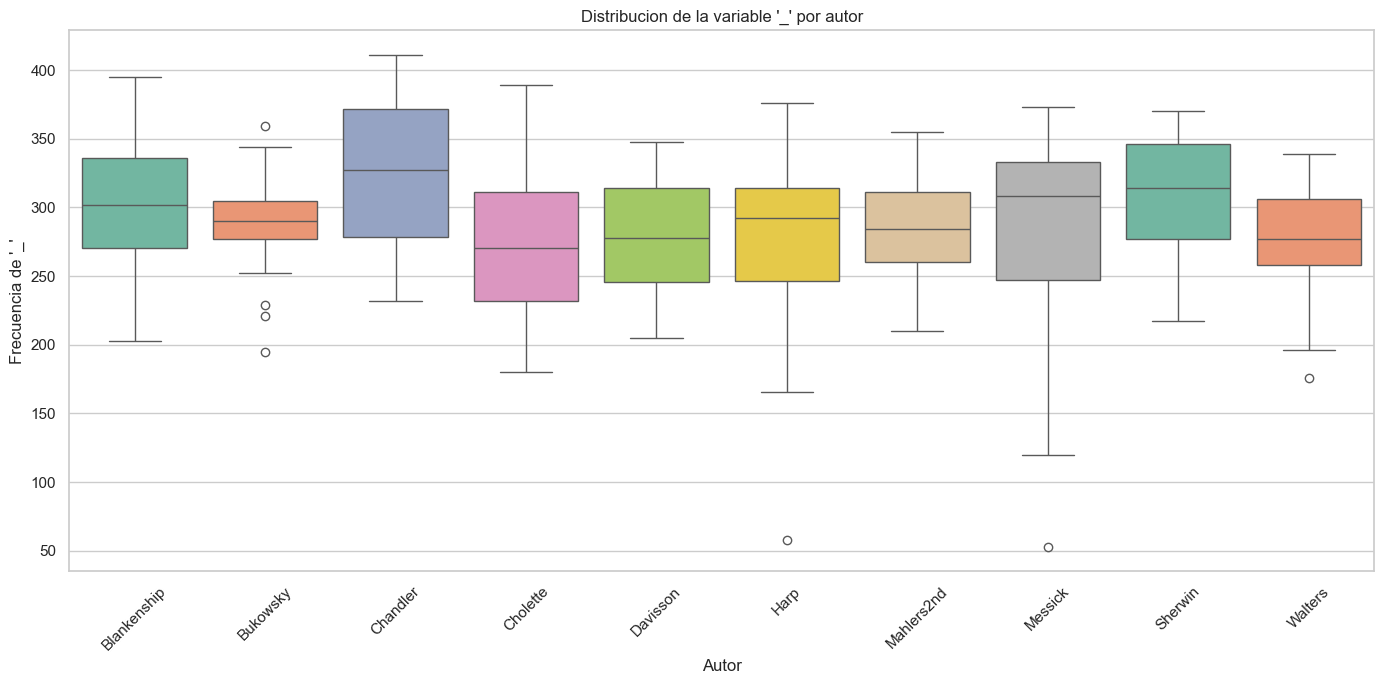

Variable frecuente analizada: _


In [14]:
sns.set_theme(style="whitegrid", context="notebook")

# 1. Frecuencia total promedio por autor
df_autor = df.copy()
df_autor["total_frecuencia"] = X.sum(axis=1)

promedio_por_autor = (
    df_autor.groupby("class")["total_frecuencia"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(16, 7))
sns.barplot(
    x=promedio_por_autor.index,
    y=promedio_por_autor.values,
    hue=promedio_por_autor.index,
    palette="viridis",
    legend=False
)
plt.title("Frecuencia total promedio por autor")
plt.xlabel("Autor")
plt.ylabel("Promedio de frecuencia total")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# 2. Boxplot de una variable frecuente por autor
variable_frecuente = X.mean().sort_values(ascending=False).index[0]
top_autores = promedio_por_autor.head(10).index

df_box = df[df["class"].isin(top_autores)].copy()
df_box[variable_frecuente] = X.loc[df_box.index, variable_frecuente]

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_box,
    x="class",
    y=variable_frecuente,
    hue="class",
    palette="Set2",
    legend=False
)
plt.title(f"Distribucion de la variable '{variable_frecuente}' por autor")
plt.xlabel("Autor")
plt.ylabel(f"Frecuencia de '{variable_frecuente}'")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Variable frecuente analizada:", variable_frecuente)

## Correlaciones

Para evitar una matriz de 10.000 x 10.000 dificil de interpretar, se analizan las 20 variables numericas con mayor varianza, ya que son las mas informativas dentro del conjunto.

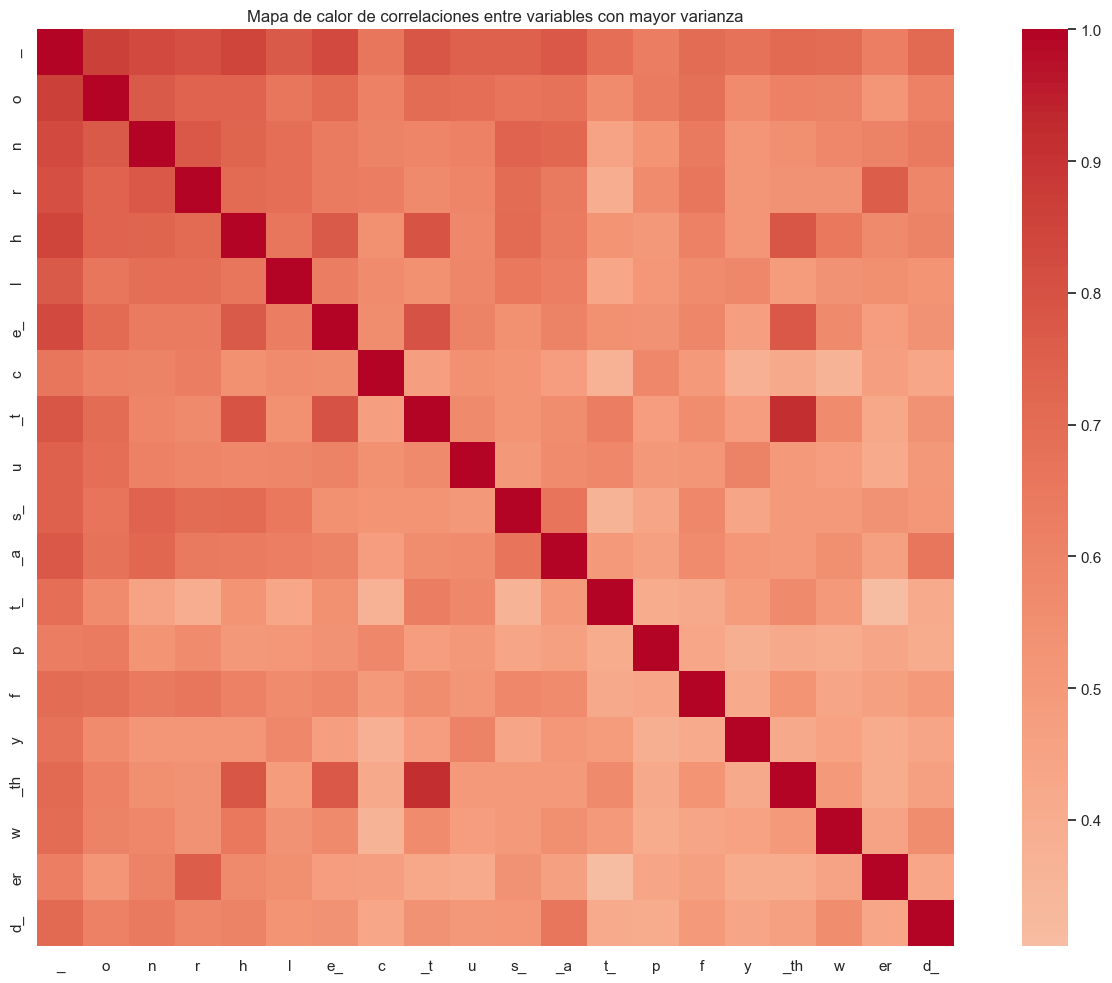

Top 10 pares de variables con mayor correlacion absoluta:
_t  _th    0.914519
_   o      0.863606
    h      0.848439
    n      0.830699
    e_     0.830474
    r      0.805456
e_  _t     0.797505
h   _t     0.789014
_   _t     0.787381
h   _th    0.783596
dtype: float64


In [13]:
corr_features = X.var().sort_values(ascending=False).head(20).index.tolist()
corr_matrix = X[corr_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Mapa de calor de correlaciones entre variables con mayor varianza")
plt.tight_layout()
plt.show()

upper_corr = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corr = (
    upper_corr.stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(10)
)

print("Top 10 pares de variables con mayor correlacion absoluta:")
print(top_corr)
